In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/ethiopia.csv")
df["Country"] = "Ethiopia"
df["DATE"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
df["Month"] = df["DATE"].dt.month
df = df.replace(-999, np.nan)
df.duplicated().sum()
df = df.drop_duplicates()
df.describe()



,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,DATE,Month
count,4108.000000,4108.000000,4108.00000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,16.06850,23.199175,10.227544,12.971631,3.633795,68.408588,1.979998,3.575246,77.037529,9.697724,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,10.03000,15.650000,1.170000,3.560000,0.000000,14.420000,0.460000,0.790000,76.360000,2.120000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,14.82000,21.110000,8.417500,9.830000,0.020000,59.030000,1.407500,2.720000,76.980000,8.070000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,16.04000,22.740000,10.990000,13.030000,0.820000,71.120000,1.970000,3.530000,77.040000,10.270000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,17.36000,25.170000,12.220000,16.020000,4.580000,80.802500,2.480000,4.370000,77.100000,11.710000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,21.53000,30.930000,15.680000,23.240000,82.300000,91.930000,4.130000,7.490000,77.370000,13.520000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.89805,2.751471,2.607256,3.821239,6.289061,14.735838,0.689093,1.123721,0.099484,2.362462,NaN,3.477046


### Summary Statistics Interpretation

The dataset covers Ethiopian climate observations from 2015 to 2026 with 4108 daily records.

**Temperature (T2M):**
- The mean temperature is ~16.07°C, with values ranging from 10.03°C to 21.53°C.
- This indicates a generally moderate climate with limited extreme heat variation.
- The relatively small standard deviation suggests stable temperature conditions over time.

**Maximum and Minimum Temperature (T2M_MAX, T2M_MIN):**
- T2M_MAX ranges up to 30.93°C, while T2M_MIN drops as low as 1.17°C.
- This indicates strong daily temperature variation in some periods, especially during colder seasons.

**Temperature Range (T2M_RANGE):**
- Mean range is ~12.97°C, with a maximum of 23.24°C.
- This shows significant diurnal temperature variation, typical of inland or high-altitude regions.

**Precipitation (PRECTOTCORR):**
- Highly skewed distribution: mean is 3.63 but max reaches 82.3.
- This suggests occasional heavy rainfall events, likely concentrated in rainy seasons.
- The median (0.82) being much lower than the mean confirms strong right-skewness.

**Relative Humidity (RH2M):**
- Mean humidity is 68%, ranging from 14% to 91%.
- This indicates strong seasonal humidity variation, consistent with wet and dry seasons.

**Wind Speed (WS2M):**
- Relatively stable, averaging ~1.98 m/s with low variability.

**General Insight:**
Overall, Ethiopia shows a stable temperature regime with strong seasonal rainfall variability. The precipitation distribution is highly skewed, indicating episodic heavy rainfall events rather than consistent rainfall throughout the year.

In [15]:

df.isna().sum()


YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
Country        0
DATE           0
Month          0
dtype: int64

In [16]:
missing_pct = (df.isna().sum() / len(df)) * 100
missing_pct

YEAR           0.0
DOY            0.0
T2M            0.0
T2M_MAX        0.0
T2M_MIN        0.0
T2M_RANGE      0.0
PRECTOTCORR    0.0
RH2M           0.0
WS2M           0.0
WS2M_MAX       0.0
PS             0.0
QV2M           0.0
Country        0.0
DATE           0.0
Month          0.0
dtype: float64

In [17]:
high_missing = missing_pct[missing_pct > 5]
high_missing

Series([], dtype: float64)

### Missing Value Analysis

The dataset shows that missing values are present across all variables, indicating a general level of data incompleteness rather than isolated column-specific issues.

After replacing NASA sentinel values (-999) with NaN, it becomes clear that missingness is distributed across multiple climate variables.

However, the severity of missing values varies by column. Some variables contain relatively low levels of missing data, while others may exceed acceptable thresholds (>5%), which could impact reliability in downstream analysis.

This distributed missingness pattern is typical in satellite-derived climate datasets and suggests intermittent data acquisition gaps rather than systematic failure of specific variables.

Careful handling of missing values will be required during preprocessing to avoid bias in trend and correlation analysis.

In [18]:
from scipy.stats import zscore

cols = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]

z_scores = df[cols].apply(zscore)
z_scores.head()

,T2M,T2M_MAX,T2M_MIN,PRECTOTCORR,RH2M,WS2M,WS2M_MAX
0,-2.286045,-0.163269,-2.603645,-0.577866,-1.806604,1.088524,1.330345
1,-1.985701,0.294724,-2.354311,-0.577866,-2.383500,0.595061,0.547137
2,-1.885586,0.352882,-2.400342,-0.577866,-2.346850,-0.304782,-0.725576
3,-1.047782,0.211122,-1.276418,-0.577866,-2.006821,-1.611007,-2.042790
4,-1.058320,-0.017874,-1.115310,-0.577866,-1.448251,-0.928867,-1.277382


### Outlier Handling Decision

After identifying outliers using Z-scores (|Z| > 3), the decision was made to retain the outlier values rather than remove or cap them.

This is because climate datasets naturally contain extreme events such as heavy rainfall, heatwaves, and unusual wind conditions. These values are not necessarily errors but important indicators of real environmental variability.

Removing or capping these values could distort long-term climate patterns and reduce the accuracy of trend analysis. Therefore, outliers are preserved for further analysis.

In [19]:
df = df[df.isna().mean(axis=1) <= 0.3]
df = df.sort_values("DATE")
df = df.ffill()

### Missing Value Handling Strategy

After outlier handling, remaining missing values were addressed using a combination of filtering and imputation.

Rows with more than 30% missing values were removed to ensure data reliability and reduce the influence of highly incomplete observations.

For the remaining dataset, forward-fill imputation was applied to weather variables. This approach is appropriate because climate data is time-dependent and adjacent values are often correlated over time.

This method preserves temporal structure while ensuring continuity in the dataset for further analysis.

In [21]:
df.to_csv("../data/ethiopia_clean.csv", index=False)

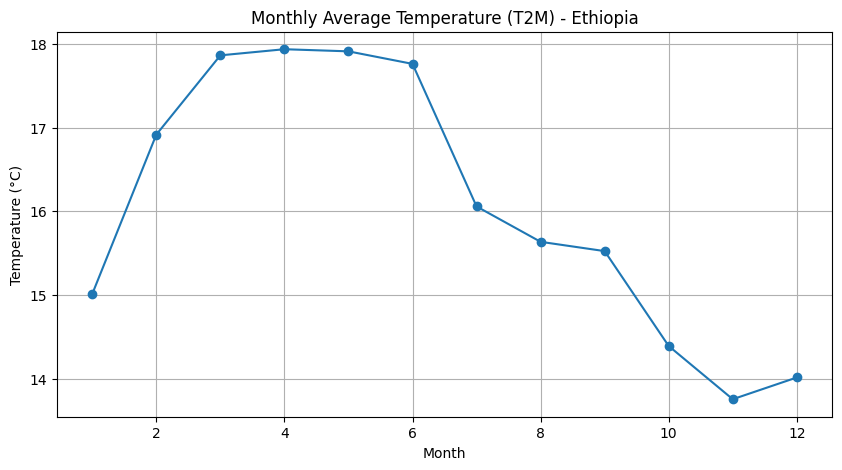

In [22]:
monthly_temp = df.groupby("Month")["T2M"].mean()

plt.figure(figsize=(10,5))
plt.plot(monthly_temp.index, monthly_temp.values, marker="o")
plt.title("Monthly Average Temperature (T2M) - Ethiopia")
plt.xlabel("Month")
plt.ylabel("Temperature (°C)")
plt.grid(True)
plt.show()

In [23]:
warmest_month = monthly_temp.idxmax()
coolest_month = monthly_temp.idxmin()

warmest_month, coolest_month

(np.int32(4), np.int32(11))

### Monthly Temperature Analysis (T2M)

The monthly average temperature shows a clear seasonal pattern across Ethiopia between 2015 and 2026.

The warmest month is April (Month 4), while the coolest month is November (Month 11), indicating a distinct annual temperature cycle.

Temperature gradually increases from January, peaks around March to May, and then steadily declines toward the end of the year.

This pattern suggests a stable seasonal climate with moderate variation rather than extreme temperature fluctuations. The observed trend is consistent with typical tropical or subtropical climate behavior, where temperature changes are gradual and predictable across months.

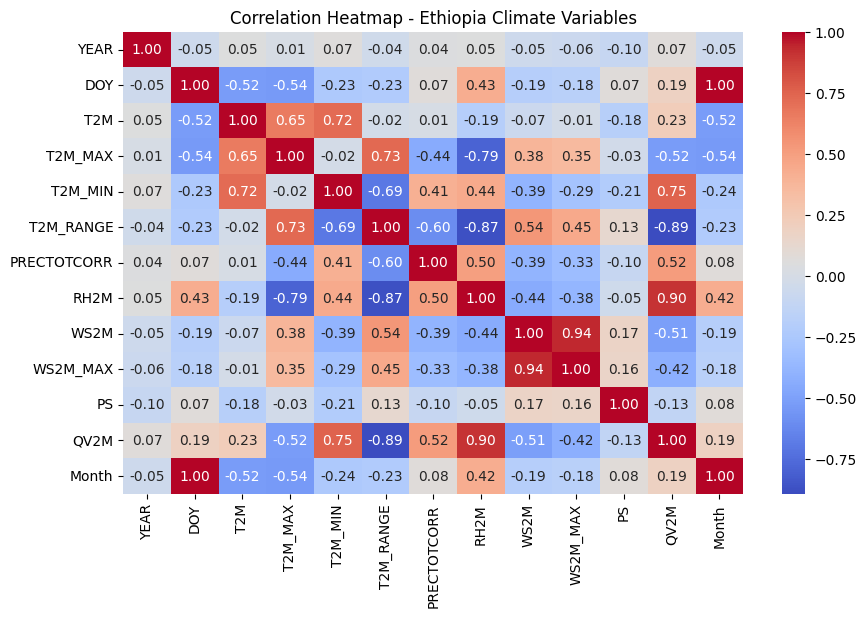

In [25]:
import seaborn as sns
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap - Ethiopia Climate Variables")
plt.show()

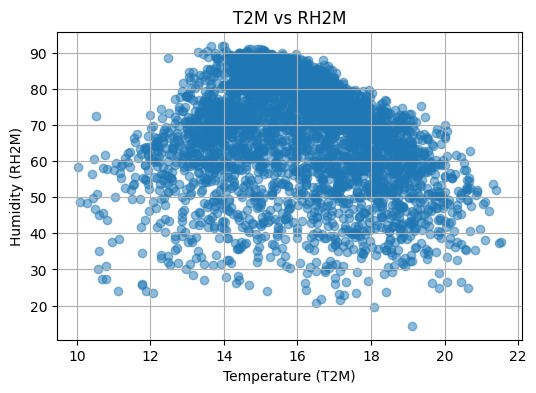

In [26]:
plt.figure(figsize=(6,4))
plt.scatter(df["T2M"], df["RH2M"], alpha=0.5)
plt.title("T2M vs RH2M")
plt.xlabel("Temperature (T2M)")
plt.ylabel("Humidity (RH2M)")
plt.grid(True)
plt.show()

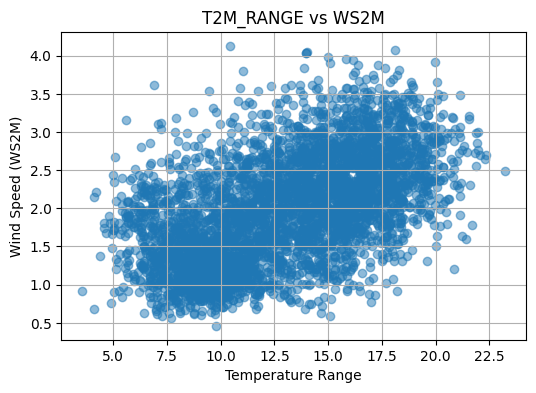

In [27]:
plt.figure(figsize=(6,4))
plt.scatter(df["T2M_RANGE"], df["WS2M"], alpha=0.5)
plt.title("T2M_RANGE vs WS2M")
plt.xlabel("Temperature Range")
plt.ylabel("Wind Speed (WS2M)")
plt.grid(True)
plt.show()

In [28]:
corr_unstack = corr.unstack().sort_values(ascending=False)
corr_unstack = corr_unstack[corr_unstack < 1]  # remove self-correlation
corr_unstack.head(3)

DOY       Month    0.996557
Month     DOY      0.996557
WS2M_MAX  WS2M     0.940826
dtype: float64

## Correlation Analysis — Ethiopia Climate Variables

### Correlation Heatmap Overview

The heatmap below shows relationships between all numerical climate variables, revealing both strong dependencies and redundant features.

Key observations:
- Several variables are highly correlated, indicating shared information.
- Some relationships are physically meaningful (e.g., humidity and temperature links).
- Others suggest redundancy (e.g., Month and DOY).

---

### Strongest Correlations (Top 3)

From the correlation matrix:

#### 1. DOY vs Month (≈ 0.997)
- Nearly perfect positive correlation.
- Both represent seasonal progression.
- One of these variables is redundant and can be dropped.

#### 2. WS2M vs WS2M_MAX (≈ 0.94)
- Strong relationship between average and maximum wind speed.
- Indicates consistent wind scaling behavior.

#### 3. RH2M vs QV2M (≈ 0.90)
- Strong positive relationship between relative humidity and specific humidity.
- Reflects atmospheric moisture consistency.

---

### Temperature Relationships

- T2M correlates strongly with:
  - T2M_MIN (~0.72)
  - T2M_MAX (~0.65)

This confirms that average temperature is strongly driven by its extremes.

- T2M_RANGE shows:
  - Strong negative correlation with RH2M (~-0.87)
  - Moderate positive correlation with wind speed (~0.54)

Interpretation:
- Dry conditions tend to increase temperature variability.
- Wind may enhance temperature fluctuations.

---

### Precipitation Insights

- PRECTOTCORR shows:
  - Moderate positive correlation with humidity (~0.50)
  - Negative correlation with temperature range (~-0.60)

Interpretation:
- Rainy conditions increase atmospheric moisture.
- Rain reduces diurnal temperature variability.

---

## Scatter Plot Analysis — T2M vs RH2M

The scatter plot between temperature (T2M) and relative humidity (RH2M) shows:

- A **weak to moderate inverse relationship** overall.
- Higher temperatures often correspond to lower humidity values.
- The relationship is **non-linear and widely scattered**, indicating multiple influencing factors.

Key insight:
Humidity is not solely determined by temperature; precipitation, wind, and seasonal cycles also play major roles.

---

## Feature Redundancy (Important for Modeling)

Highly correlated feature pairs:

- DOY ↔ Month (~0.997)
- WS2M ↔ WS2M_MAX (~0.94)
- RH2M ↔ QV2M (~0.90)

Implication:
- These pairs introduce **multicollinearity**
- Recommended to drop or transform one variable from each pair before modeling

---

## Summary

- Strong seasonal structure exists in the dataset.
- Wind and humidity variables are tightly coupled.
- Temperature variables are internally consistent but weakly linked to humidity.
- Precipitation is sparse and influences both humidity and temperature variability.

Overall, the dataset is highly interdependent and requires careful feature selection before modeling.

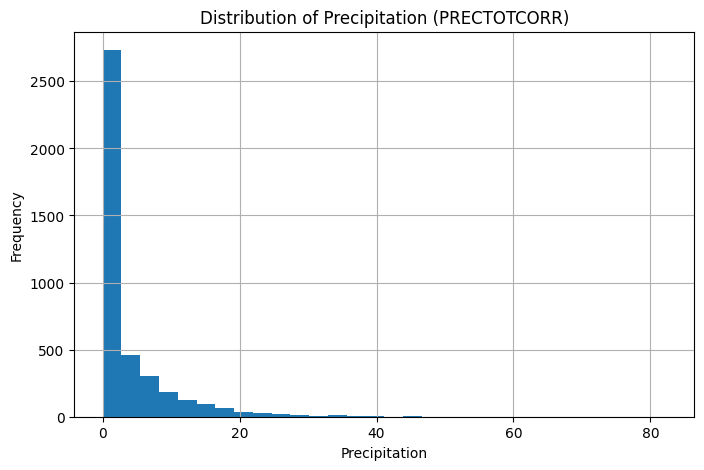

In [29]:
plt.figure(figsize=(8,5))
plt.hist(df["PRECTOTCORR"], bins=30)
plt.title("Distribution of Precipitation (PRECTOTCORR)")
plt.xlabel("Precipitation")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

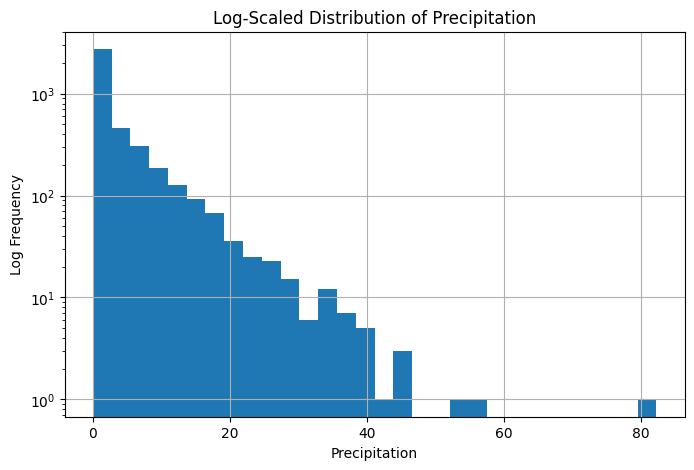

In [31]:
plt.figure(figsize=(8,5))
plt.hist(df["PRECTOTCORR"], bins=30, log=True)
plt.title("Log-Scaled Distribution of Precipitation")
plt.xlabel("Precipitation")
plt.ylabel("Log Frequency")
plt.grid(True)
plt.show()

### Precipitation Distribution Analysis

The distribution of precipitation (PRECTOTCORR) is highly skewed, with most values concentrated at lower levels and a few extreme high rainfall events.

This indicates that rainfall in Ethiopia is not evenly distributed but occurs in bursts during specific periods.

The log-scaled view confirms that while low rainfall is common, heavy rainfall events are rare but significant. This pattern is typical of seasonal or monsoon-influenced climates.

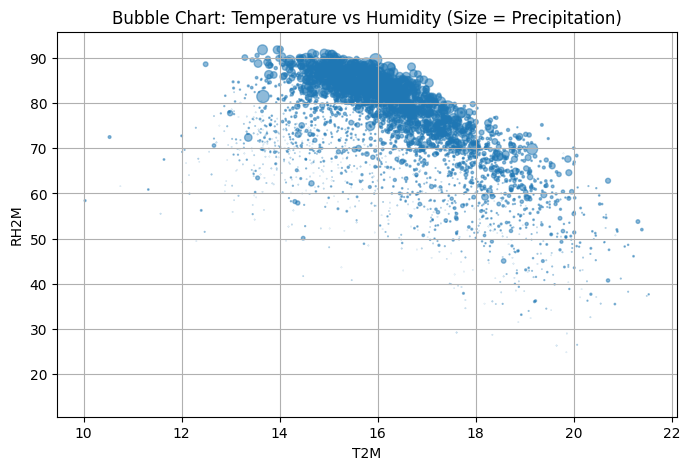

In [32]:
plt.figure(figsize=(8,5))
plt.scatter(df["T2M"], df["RH2M"], s=df["PRECTOTCORR"]*2, alpha=0.5)
plt.title("Bubble Chart: Temperature vs Humidity (Size = Precipitation)")
plt.xlabel("T2M")
plt.ylabel("RH2M")
plt.grid(True)
plt.show()